# Capacity allocation: protecting seats for full-fare demand

An airline sells a fixed capacity of $C = 100$ seats in two fare classes: a full fare $p_f = 150$ and a discount fare $p_d = 100$. Discount demand books early; full-fare demand arrives later. The revenue manager must decide how many seats to **protect** for full-fare passengers — equivalently, how many discount bookings to allow. Protect too few and high-value seats are *diluted* by early discount sales; protect too many and they *spoil* empty if full-fare demand falls short.

Demand in each class is random (here, Normal truncated at zero). We solve for the protection level $y$ two ways and check that they agree:

- **By simulation** — pick the $y$ that maximizes expected revenue over many demand draws.
- **By Littlewood's rule** — protect up to the point where the probability that full-fare demand *exceeds* $y$ equals the fare ratio, $\Pr(D_f > y) = p_d / p_f$. Notably, the optimal $y$ does not depend on the discount-demand forecast at all.

This is the two-class case of Phillips, Chapter 9, and is a newsvendor problem in disguise: protecting one more seat trades the *overage* cost of a spoiled seat against the *underage* cost of a diluted one.

## Setup

Fix the random seed so the simulated demand draws — and therefore every number below — are reproducible.

In [1]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.stats import norm
np.random.seed(666)

## Optimal protection level by simulation

We draw a common set of full-fare and discount demand realizations, then search over protection levels for the one that maximizes mean revenue. Discount bookings fill the unprotected seats first; full-fare demand then takes whatever remains. We minimize the *negative* of expected revenue because `scipy` provides minimizers.

In [2]:
# Fares and capacity
full_fare_price = 150
discount_price  = 100
plane_capacity  = 100

num_simulations = 200_000  # more draws -> more precise expected-revenue estimates

# Demand distributions (Normal, truncated below at 0)
full_fare_mean     = 56
full_fare_std      = 23
discount_fare_mean = 88
discount_fare_std  = 44

def simulate_demand(mean, std, num_simulations):
    """Draw non-negative demand from a Normal, clipping negative draws to 0."""
    demand = np.random.normal(mean, std, num_simulations)
    return np.where(demand < 0, 0, demand)

# Draw once, outside the objective, so every protection level is evaluated on the same realizations
full_fare_demand = simulate_demand(full_fare_mean, full_fare_std, num_simulations)
discount_demand  = simulate_demand(discount_fare_mean, discount_fare_std, num_simulations)

def expected_revenue(protection_level):
    discounted_sales = np.minimum(plane_capacity - protection_level, discount_demand)
    full_fare_sales  = np.minimum(plane_capacity - discounted_sales, full_fare_demand)
    revenue = full_fare_price * full_fare_sales + discount_price * discounted_sales
    return -np.mean(revenue)  # negate: maximize revenue via a minimizer

result = minimize_scalar(expected_revenue, bounds=(0, plane_capacity), method='bounded')

print(f"The optimal protection level to maximize expected revenue is: {round(result.x, 2)}")

The optimal protection level to maximize expected revenue is: 46.05


## Littlewood's rule: the closed-form answer

Littlewood's rule sets the protection level $y$ so that $\Pr(D_f > y) = p_d / p_f$, where $D_f$ is full-fare demand. Equivalently, $y$ is the $\left(1 - p_d/p_f\right)$ quantile of $D_f$. With $D_f \sim \mathcal{N}(56, 23^2)$ and a fare ratio of $p_d/p_f = 100/150 = 2/3$, this should reproduce the simulated protection level above — confirming that the Monte Carlo search recovers the textbook rule.

In [3]:
fare_ratio = discount_price / full_fare_price
percentile = 1 - fare_ratio  # Littlewood: y is the (1 - p_d/p_f) quantile of full-fare demand

full_fare_demand_percentile = norm.ppf(percentile, loc=full_fare_mean, scale=full_fare_std)

print(f"The theoretical percentile {round(percentile*100, 2)}% of full-fare demand is: {round(full_fare_demand_percentile, 2)}")

The theoretical percentile 33.33% of full-fare demand is: 46.09


## Revenue across protection levels

To see the trade-off, we sweep the protection level from 0 to 100 and plot the full revenue distribution (boxplots) alongside expected revenue (green line). The peak sits at the optimal protection level found above (red dashed line); the curve is flat near the top, so small misjudgments cost little.

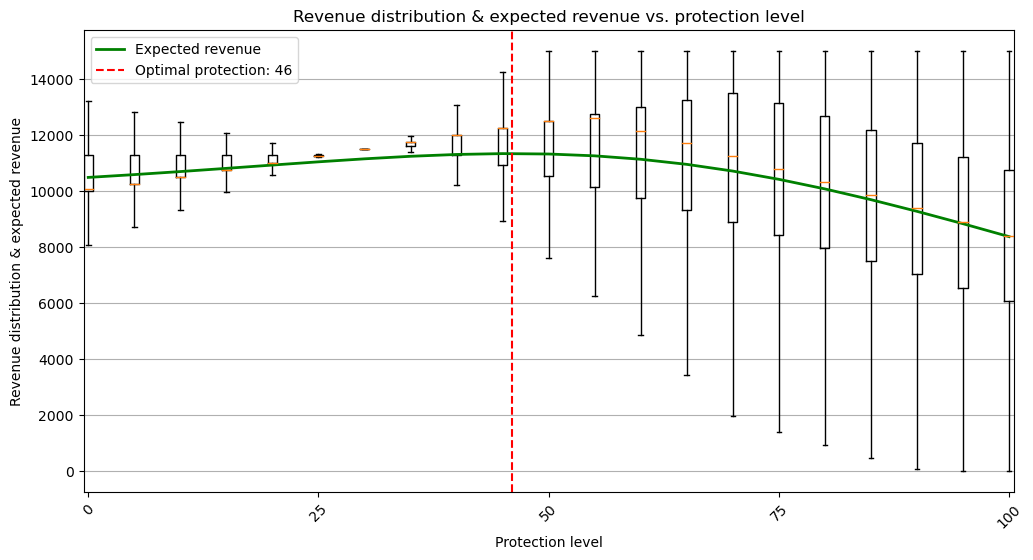

In [4]:
import matplotlib.pyplot as plt

protection_levels = list(range(0, 101, 5))
revenue_distributions = []
expected_revenues = []

def calculate_revenue(protection_level):
    discounted_sales = np.minimum(plane_capacity - protection_level, discount_demand)
    full_fare_sales  = np.minimum(plane_capacity - discounted_sales, full_fare_demand)
    return full_fare_price * full_fare_sales + discount_price * discounted_sales

for protection in protection_levels:
    revenues = calculate_revenue(protection)
    revenue_distributions.append(revenues)
    expected_revenues.append(np.mean(revenues))

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(revenue_distributions, positions=protection_levels, widths=1.0, showfliers=False)
ax.plot(protection_levels, expected_revenues, color='g', linewidth=2, label='Expected revenue')

step = 5
ax.set_xticks(protection_levels[::step])
ax.set_xticklabels(protection_levels[::step], rotation=45)
ax.set_xlabel("Protection level")
ax.set_ylabel("Revenue distribution & expected revenue")
ax.set_title("Revenue distribution & expected revenue vs. protection level")

optimal_protection = int(result.x)
ax.axvline(x=optimal_protection, color='r', linestyle='--', label=f'Optimal protection: {optimal_protection}')

ax.legend()
ax.grid(axis='y')
plt.show()